In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import cmasher as cmr
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pathlib import Path
from sklearn.linear_model import LinearRegression
from scipy.signal import savgol_filter

from models import CondSM

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 11,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 9,    # affects horizontal colorbar ticks
    "ytick.labelsize": 9,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 9,
})

cuda


In [3]:
dataset_num = 1
model_dir = Path(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/data_uni_{dataset_num}/')

#state_dict = torch.load(model_dir / f'sm_uni_{dataset_num}.pth', weights_only=False, map_location='cpu')
state_dict = torch.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/models/sm_vMB_na=200.pth', weights_only=False, map_location='cpu')

model = CondSM(state_dict['layer_dims'], dropout_p=state_dict['dropout'], batch_norm=state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])
print('model loaded')

model loaded


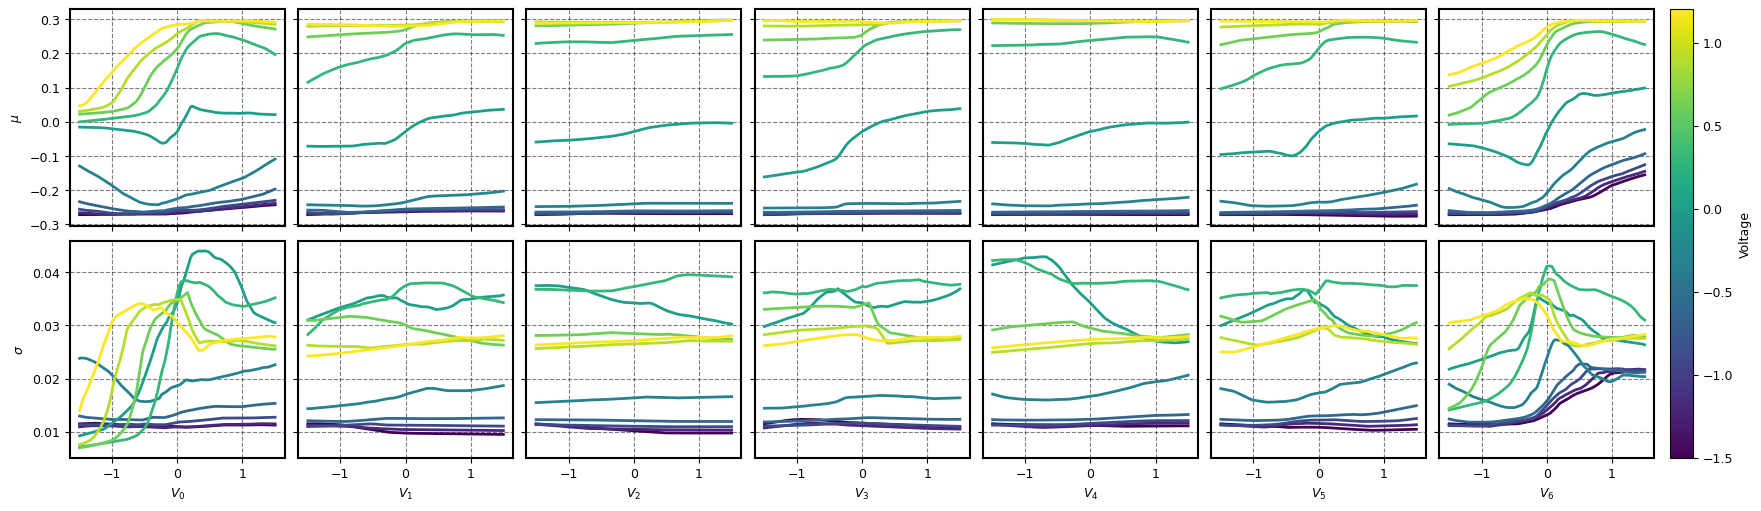

In [4]:
num_voltages = model.layer_dims[0]
num_outputs = model.layer_dims[-1]
input_idx = 0

N = 200
voltage_range = torch.linspace(-1.5, 1.5, N)

v_quantiles = torch.arange(-1.5, 1.5, 0.3)

e_indices = [i for i in range(num_voltages)]

fig, ax = plt.subplots(nrows=2, ncols=num_voltages, figsize=(2.5 * num_voltages, 5), sharex='col', sharey='row', constrained_layout=True)

cmap = plt.get_cmap('viridis')
norm = plt.Normalize(vmin=v_quantiles[0], vmax=v_quantiles[-1])
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax.ravel().tolist(), label=rf'Voltage', pad=0.01)
std_l = []
mu_l = []
model.eval()
for i in range(num_voltages):
    for v_q in v_quantiles:
        input_tensor = torch.empty(N, num_voltages, dtype=torch.float32)
        input_tensor[..., [col for col in range(num_voltages) if col != i]] = v_q
        input_tensor[:, i] = voltage_range

        I = model(input_tensor)
        mu = I[..., 0].detach().numpy()
        std = np.exp(I[..., 1].detach().numpy())
        std_l.append(std)
        if i == 0:
            ax[0, i].set_ylabel(r'$\mu$')
            ax[1, i].set_ylabel(r'$\sigma$')


        ax[0, i].plot(voltage_range, mu, color=cmap(norm(v_q)), lw=2.0, zorder=5)
        ax[1, i].plot(voltage_range, std, color=cmap(norm(v_q)), lw=2.0, zorder=5)

        ax[0, i].tick_params(labelbottom=False)
        #ax[0, i].set_title(rf'$V_{i}$')
        
        #ax[0, i].set_facecolor('lightgrey')
        #ax[1, i].set_facecolor('lightgrey')

        ax[0, i].spines[:].set_linewidth(1.5)
        ax[1, i].spines[:].set_linewidth(1.5)

        ax[0, i].grid(True, which='both', c='k', ls='dashed', alpha=.5)
        ax[1, i].grid(True, which='both', c='k', ls='dashed', alpha=.5)

        ax[1, i].set_xlabel(rf'$V_{i}$') 

#plt.savefig(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/plots/sm_uni_{dataset_num}.pdf', bbox_inches='tight')

## 2.) Interactions between adjacent electrodes near the output

tensor([-1.3228,  0.9517,  1.4988,  0.7446, -1.2111])
-0.02460788
0.106768966
0.8344 %


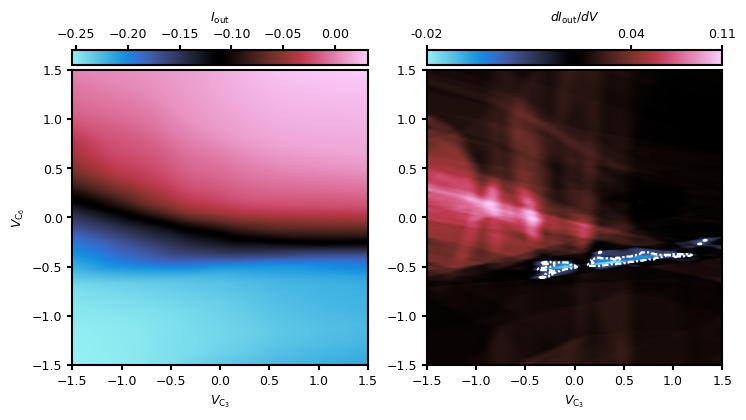

In [5]:
c_sweep_index = 6
input_idx = 3

in_features = 7
min_v = -1.5
max_v = 1.5

N = 500
input_range = torch.linspace(min_v, max_v, N)
c_sweep_range = torch.linspace(min_v, max_v, N)
dx = float((max_v - min_v) / (N - 1))

np.random.seed()
other_controls = torch.tensor(np.random.uniform(min_v, max_v, 5)).type(torch.float32)
print(other_controls)
window_length = 51
poly_order = 3

I_lines = []
raw_output = []
model.eval()
other_control_cols = []
for k in range(in_features):
    if k not in (c_sweep_index, input_idx):
        other_control_cols.append(k)        

for c_v in c_sweep_range:
    input_tensor = torch.empty(N, 7, dtype=torch.float32)
    input_tensor[:, c_sweep_index] = c_v
    for l, other_c_v in zip(other_control_cols, other_controls):
        input_tensor[:, l] = other_c_v
    input_tensor[:, input_idx] = input_range
    input_tensor = input_tensor
    with torch.no_grad():
        y_out = model(input_tensor).detach().cpu().squeeze().numpy()
    y_out = y_out[:, 0]
    I_smooth = savgol_filter(x=y_out, window_length=window_length, polyorder=poly_order, delta=dx, mode='interp')
    I_lines.append(I_smooth)
    raw_output.append(y_out)
    
c_i_mat = np.stack(I_lines)

grad_list = []
for line in raw_output:
    #dIdV = np.gradient(line, dx)
    dIdV = savgol_filter(x=line, window_length=window_length, polyorder=poly_order, deriv=1, delta=dx, mode='interp')
    grad_list.append(dIdV)
grad = np.stack(grad_list)    

cmap = cmr.rainforest
cmap = plt.get_cmap('cmr.redshift')
print(grad.min())
print(grad.max())
if grad.min() < 0.0 and grad.max() > 0.0:
    norm = mcolors.TwoSlopeNorm(vmin=grad.min(), vcenter=0.0, vmax=grad.max())
else:
    norm = plt.Normalize(vmin=grad.min(), vmax=grad.max())

latex_lw = 404.02908
in_inch = latex_lw / 72.27

scale=1.5
fig, ax = plt.subplots(ncols=2, figsize=(scale*in_inch, scale*in_inch))
fig.subplots_adjust(top=0.9, bottom=0.08)

ax[0].spines[:].set_linewidth(1.5)
ax[1].spines[:].set_linewidth(1.5)

ax[0].tick_params(width=1.5)
ax[1].tick_params(width=1.5)

extent = [input_range[0], input_range[-1], c_sweep_range[0], c_sweep_range[-1]]
im_0 = ax[0].imshow(c_i_mat, origin='lower', extent=extent, cmap=cmap)
im_1 = ax[1].imshow(grad, origin='lower', extent=extent, cmap=cmap, norm=norm)

divider_0 = make_axes_locatable(ax[0])
cax_0 = divider_0.append_axes('top', size='5%', pad=0.05)
cb_0 = fig.colorbar(im_0, cax=cax_0, orientation='horizontal')
cb_0.ax.xaxis.set_ticks_position('top')
cb_0.ax.xaxis.set_label_position('top')
cb_0.outline.set_linewidth(1.5)
cb_0.ax.xaxis.set_tick_params(width=1.5)
cb_0.set_label(label=r'$I_{\mathrm{out}}$')

divider_1 = make_axes_locatable(ax[1])
cax_1 = divider_1.append_axes('top', size='5%', pad=0.05)
#ticks = np.linspace(grad.min(), grad.max(), 3)
ticks = [grad.min(), (grad.min() + grad.max()) / 2.0, grad.max()]
cb_1 = fig.colorbar(im_1, cax=cax_1, orientation='horizontal')
cb_1.ax.xaxis.set_ticks_position('top')
cb_1.ax.xaxis.set_label_position('top')
cb_1.outline.set_linewidth(1.5)
cb_1.ax.xaxis.set_tick_params(width=1.5)
cb_1.set_label(label=r'$dI_{\mathrm{out}} / dV$')
cb_1.set_ticks(ticks)
cb_1.ax.set_xticklabels([f'{t:.2f}' for t in ticks])

eps = 1e-9
neg_mask = grad < -1e-2
print(f'{100.0 * neg_mask.sum() / N ** 2} %')
#print(neg_mask.mean())
cs = ax[1].contour(neg_mask.astype(float), levels=[0.5], colors='w', linewidths=1.6, linestyles=[(0, (3, 1, 1, 1))], extent=extent)

ax[0].set_xlabel(fr'$V_{{\mathrm{{C_{{{input_idx}}}}}}}$')
ax[0].set_ylabel(fr'$V_{{\mathrm{{C_{{{c_sweep_index}}}}}}}$')

ax[1].set_xlabel(fr'$V_{{\mathrm{{C_{{{input_idx}}}}}}}$')

#plt.savefig(f'/home/hd/hd_hd/hd_gy283/kmc_project/plots/ndr_regions_c={c_sweep_index}.pdf', bbox_inches='tight')
plt.show()